# Pneumonia Detection — Attention (CBAM) + GradCAM
Adds **CBAM attention** (channel + spatial) to the CNN and explains predictions with **GradCAM**.

## 1. Imports & GPU Check

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus if gpus else 'None — running on CPU')

I0000 00:00:1773823960.430072  325334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773823960.431714  325334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773823960.490818  325334 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773823962.329914  325334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

GPUs: None — running on CPU


E0000 00:00:1773823963.409204  325334 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773823963.409923  325678 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773823963.467682  325334 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Configuration

In [2]:
DATA_DIR   = '../data/raw/chest_xray'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
VAL_DIR    = os.path.join(DATA_DIR, 'val')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
MODEL_PATH = '../models/pneumonia_cnn_cbam.keras'
PLOTS_DIR  = '../results/plots'
GRADCAM_DIR = '../results/gradcam_outputs'

os.makedirs('../models',  exist_ok=True)
os.makedirs(PLOTS_DIR,    exist_ok=True)
os.makedirs(GRADCAM_DIR,  exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
CLASSES    = ['NORMAL', 'PNEUMONIA']
GRADCAM_LAYER = 'conv4'   # last conv layer — best spatial resolution for GradCAM

## 3. Data Generators

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, fill_mode='nearest'
)
eval_datagen = ImageDataGenerator(rescale=1./255)

common = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
              color_mode='grayscale', class_mode='binary')

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, shuffle=True,  **common)
val_gen   = eval_datagen.flow_from_directory(VAL_DIR,   shuffle=False, **common)
test_gen  = eval_datagen.flow_from_directory(TEST_DIR,  shuffle=False, **common)

print(f'Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train: 5216 | Val: 16 | Test: 624


## 4. CBAM Attention Blocks
**Channel Attention** — *what* features to focus on (Squeeze-and-Excitation style).  
**Spatial Attention** — *where* in the image to focus.  
Both are applied sequentially after Conv blocks 3 and 4.

In [4]:
from tensorflow.keras import layers, Model, Input

def channel_attention(x, ratio=8):
    filters = x.shape[-1]
    avg = layers.GlobalAveragePooling2D()(x)
    mx  = layers.GlobalMaxPooling2D()(x)
    dense1 = layers.Dense(filters // ratio, activation='relu')
    dense2 = layers.Dense(filters, activation='sigmoid')
    scale = layers.Add()([dense2(dense1(avg)), dense2(dense1(mx))])
    scale = layers.Reshape((1, 1, filters))(scale)
    return layers.Multiply()([x, scale])

def spatial_attention(x):
    avg = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    mx  = layers.Lambda(lambda t: tf.reduce_max(t,  axis=-1, keepdims=True))(x)
    mask = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(
               layers.Concatenate(axis=-1)([avg, mx]))
    return layers.Multiply()([x, mask])

def cbam_block(x, ratio=8):
    x = channel_attention(x, ratio)
    x = spatial_attention(x)
    return x

## 5. Build CNN + CBAM Model

In [5]:
def build_attention_model():
    inputs = Input(shape=(*IMAGE_SIZE, 1), name='input')

    # Block 1
    x = layers.Conv2D(32,  3, padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64,  3, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 3 + CBAM
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D()(x)

    # Block 4 + CBAM  ← GradCAM target
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='conv4')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D()(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    return Model(inputs, outputs, name='pneumonia_cnn_cbam')

model = build_attention_model()
model.summary()

Model: "pneumonia_cnn_cbam"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 224, 224,  │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      2,064 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,176 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 128) │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 56, 56, 1) │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 509,687 (1.94 MB)

 Trainable params: 508,727 (1.94 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compile & Train

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
]

history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1773823964.798703  325334 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8207 - loss: 0.3598
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../models/pneumonia_cnn_cbam.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8717 - loss: 0.2839 - val_accuracy: 0.5000 - val_loss: 13.5106 - learning_rate: 0.0010
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9193 - loss: 0.2063
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9208 - loss: 0.1969 - val_accuracy: 0.5000 - val_loss: 8.6585 - learning_rate: 0.0010
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9239 - loss: 0.1933
Epoch 3: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9293 - loss: 0.1834 - val_accuracy: 0.5000 - val_loss: 8.3974 - learning_rate: 0.0010
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9376 - loss: 0.1571
Epoch 4: val_accuracy improved from 0.

## 7. Training Curves

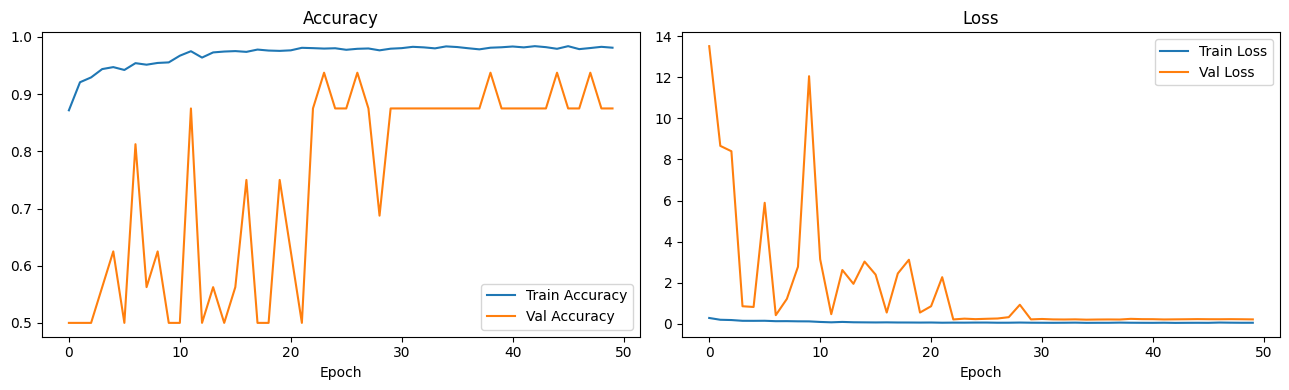

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (tk, vk), title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history.history[tk], label=f'Train {title}')
    ax.plot(history.history[vk], label=f'Val {title}')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cbam_training_curves.png'), dpi=150)
plt.show()

## 8. Evaluate on Test Set

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 300ms/step - accuracy: 0.8734 - loss: 0.3618

Test Loss: 0.3618  |  Test Accuracy: 0.8734
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.80      0.88      0.84       234
   PNEUMONIA       0.92      0.87      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.87      0.87       624
weighted avg       0.88      0.87      0.87       624



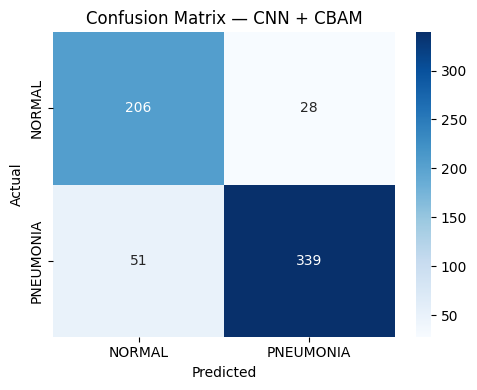

In [8]:
test_gen.reset()
loss, acc = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}')

test_gen.reset()
y_true = test_gen.classes
y_pred = (model.predict(test_gen, verbose=1).ravel() >= 0.5).astype(int)

print('\n── Classification Report ──────────────────────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('Confusion Matrix — CNN + CBAM')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cbam_confusion_matrix.png'), dpi=150)
plt.show()

## 9. GradCAM — How It Works
GradCAM computes the gradient of the predicted class score with respect to the **last conv layer's feature maps**.  
Channels are weighted by their global-average gradient → summed → ReLU → resized to input resolution.  
Bright regions = areas the model focused on to make its decision.

In [9]:
def compute_gradcam(model, img_array, layer_name):
    """Returns a normalised (H', W') heatmap."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_out, preds = grad_model(inputs)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, conv_out)               # (1, H', W', C)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))       # (C,)
    cam     = tf.reduce_sum(conv_out[0] * weights, axis=-1)  # (H', W')
    cam     = tf.nn.relu(cam).numpy()
    cam     = cam - cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    return cam


def show_gradcam(model, img_array, layer_name, title='', ax=None):
    """Display original | heatmap | overlay side-by-side."""
    H, W = img_array.shape[1], img_array.shape[2]
    heatmap = compute_gradcam(model, img_array, layer_name)
    heatmap_r = cv2.resize(heatmap, (W, H))
    base = img_array.squeeze()
    base_rgb = np.stack([base] * 3, axis=-1)
    overlay  = np.clip(0.5 * base_rgb + 0.4 * plt.cm.jet(heatmap_r)[:, :, :3], 0, 1)

    show = ax is None
    if show:
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(base, cmap='gray');         ax[0].set_title('Original');  ax[0].axis('off')
    ax[1].imshow(heatmap_r, cmap='jet');     ax[1].set_title('GradCAM');   ax[1].axis('off')
    ax[2].imshow(overlay);                   ax[2].set_title('Overlay');   ax[2].axis('off')
    if title: plt.suptitle(title, fontsize=11)
    if show: plt.tight_layout(); plt.show()

## 10. GradCAM — Single Image

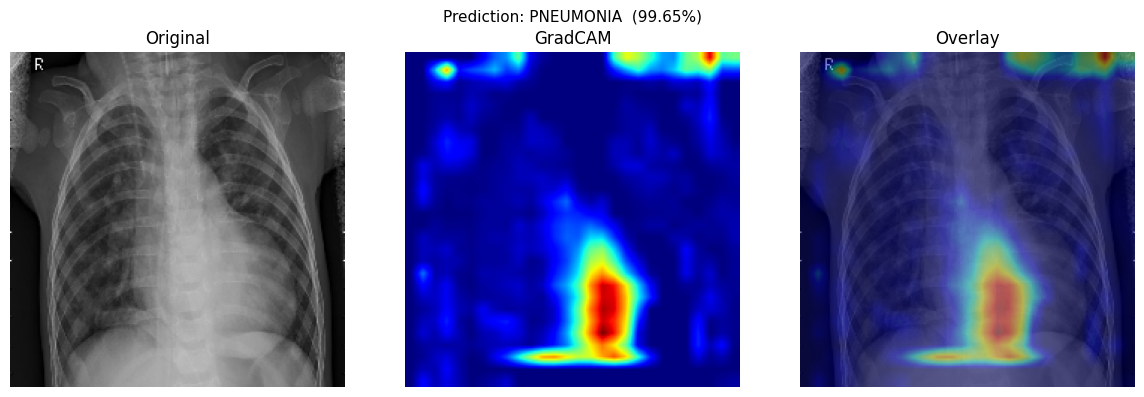

In [10]:
SAMPLE = os.path.join(TEST_DIR, 'PNEUMONIA',
                      os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])

img = load_img(SAMPLE, color_mode='grayscale', target_size=IMAGE_SIZE)
arr = np.expand_dims(img_to_array(img) / 255.0, axis=0)   # (1, 224, 224, 1)

prob  = model.predict(arr, verbose=0)[0][0]
label = CLASSES[int(prob >= 0.5)]

show_gradcam(model, arr, GRADCAM_LAYER,
             title=f'Prediction: {label}  ({prob:.2%})')

## 11. GradCAM — Batch (6 Test Images)

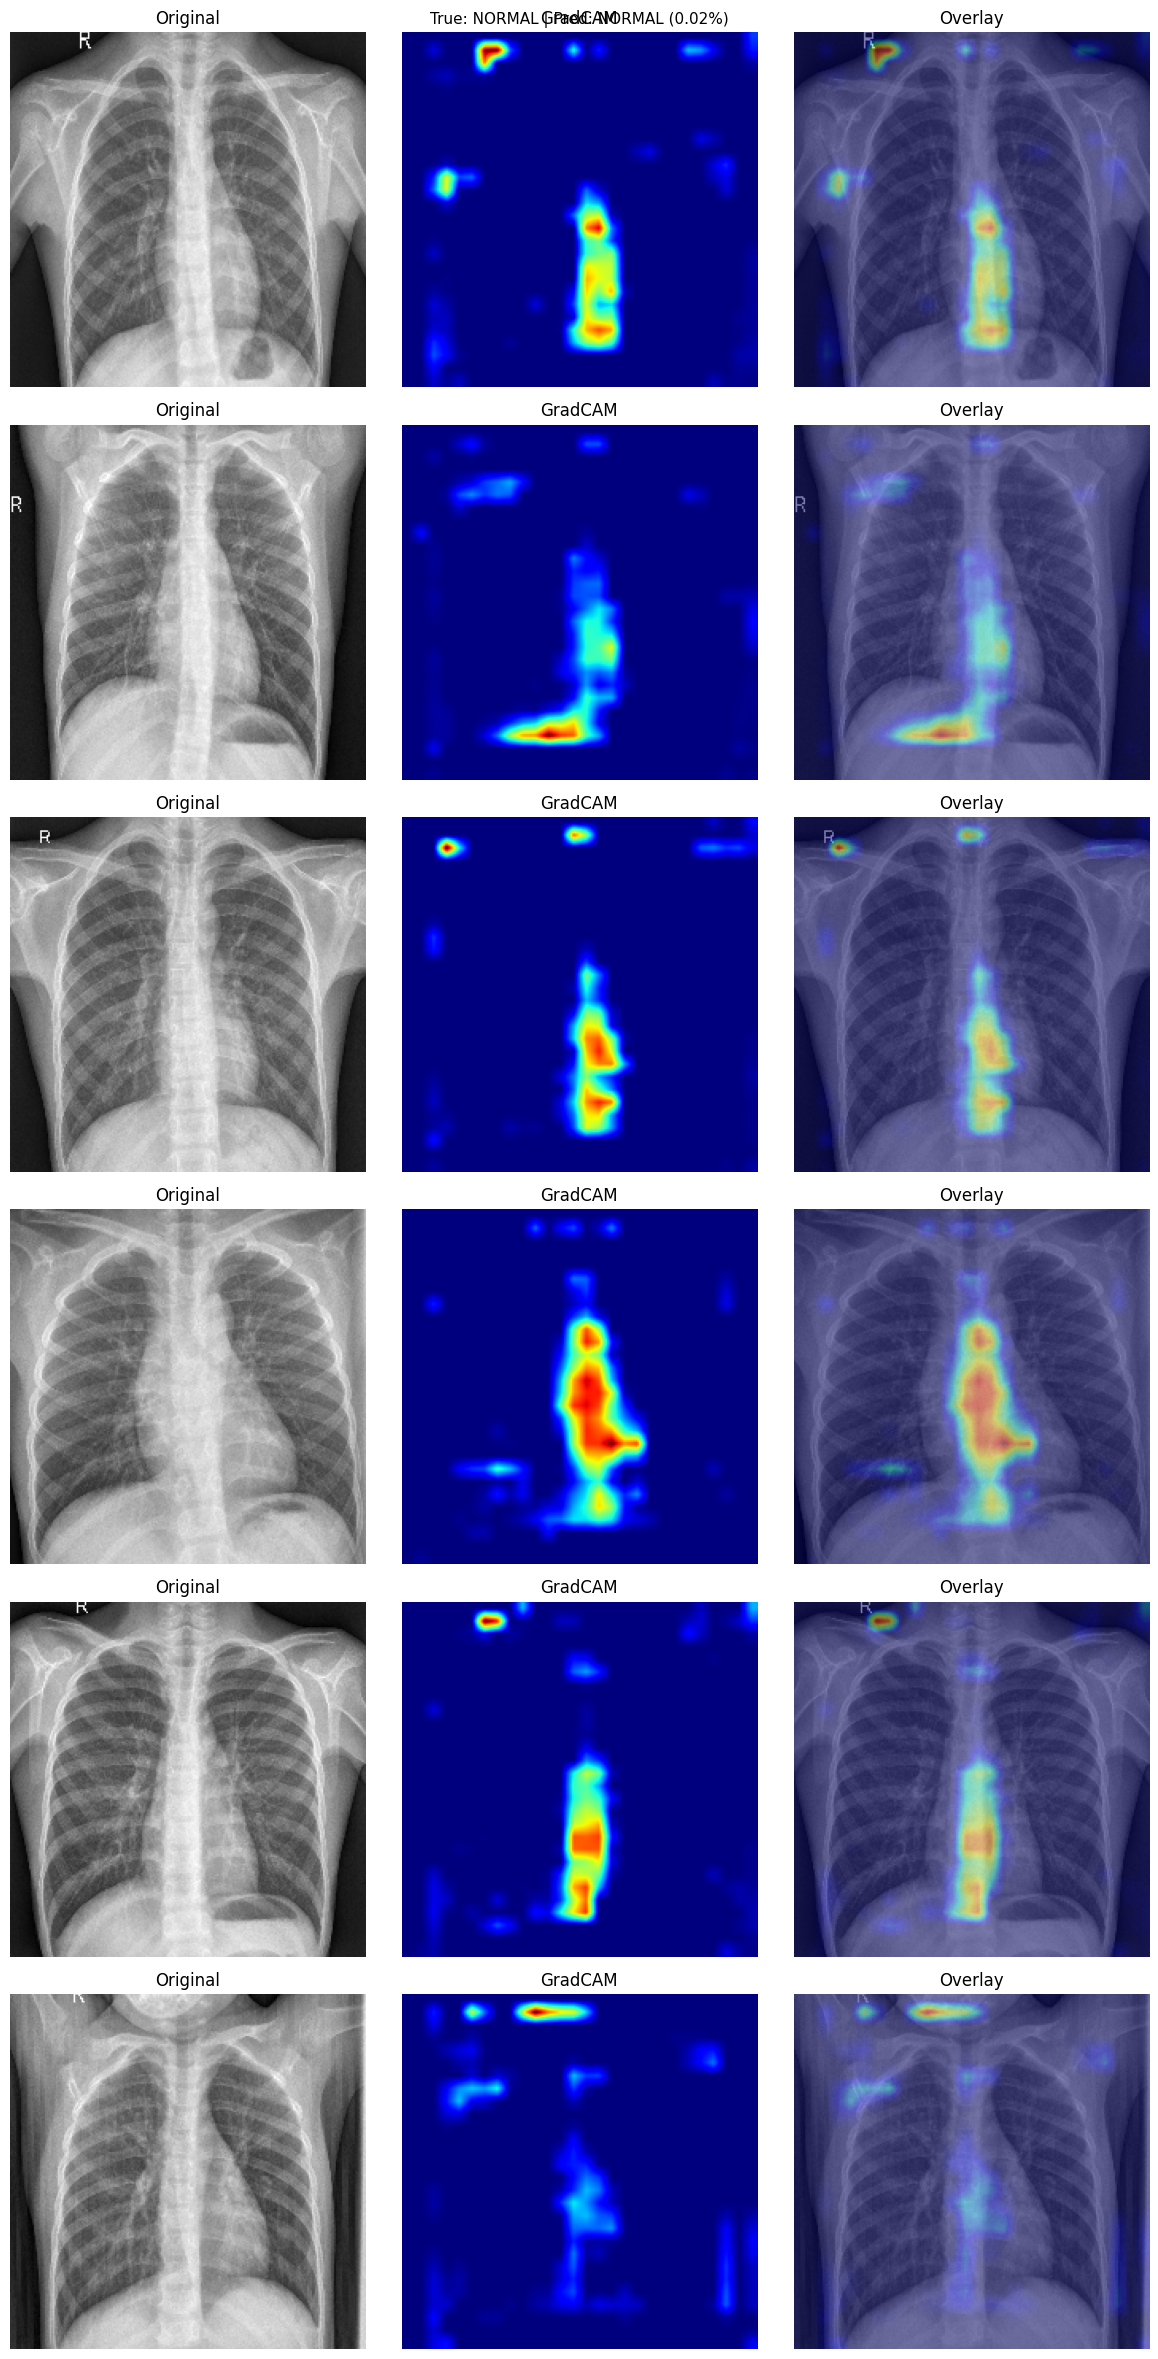

Saved → ../results/gradcam_outputs/gradcam_batch.png


In [11]:
N = 6
test_gen.reset()
images, labels = next(test_gen)
images, labels = images[:N], labels[:N]

fig, axes = plt.subplots(N, 3, figsize=(12, 4 * N))

for i, (img, lbl) in enumerate(zip(images, labels)):
    arr   = np.expand_dims(img, axis=0)
    prob  = model.predict(arr, verbose=0)[0][0]
    pred  = CLASSES[int(prob >= 0.5)]
    truth = CLASSES[int(lbl)]
    show_gradcam(model, arr, GRADCAM_LAYER,
                 title=f'True: {truth} | Pred: {pred} ({prob:.2%})',
                 ax=axes[i])

plt.tight_layout()
plt.savefig(os.path.join(GRADCAM_DIR, 'gradcam_batch.png'), dpi=150)
plt.show()
print(f'Saved → {GRADCAM_DIR}/gradcam_batch.png')

## 12. GradCAM — Compare NORMAL vs PNEUMONIA

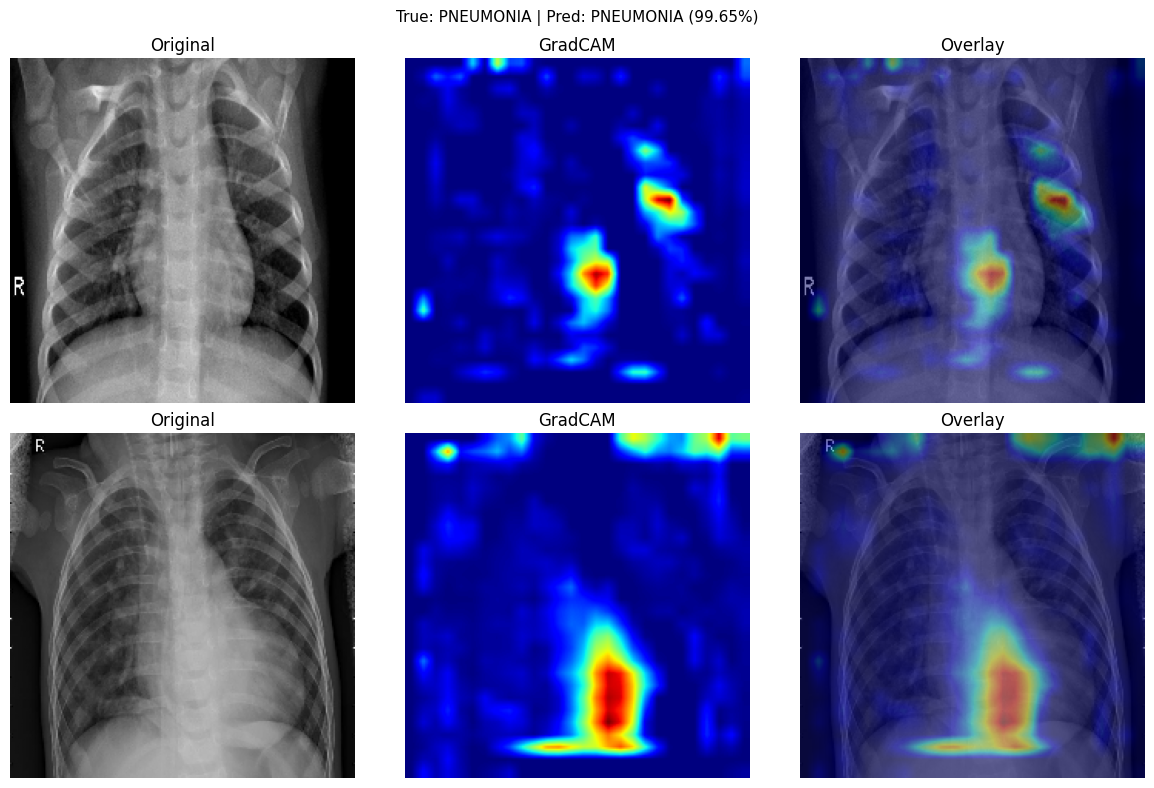

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    sample = os.path.join(TEST_DIR, cls,
                          os.listdir(os.path.join(TEST_DIR, cls))[0])
    img = load_img(sample, color_mode='grayscale', target_size=IMAGE_SIZE)
    arr = np.expand_dims(img_to_array(img) / 255.0, axis=0)
    prob  = model.predict(arr, verbose=0)[0][0]
    pred  = CLASSES[int(prob >= 0.5)]
    show_gradcam(model, arr, GRADCAM_LAYER,
                 title=f'True: {cls} | Pred: {pred} ({prob:.2%})',
                 ax=axes[row])

plt.tight_layout()
plt.savefig(os.path.join(GRADCAM_DIR, 'gradcam_comparison.png'), dpi=150)
plt.show()

## 13. Save Model

In [13]:
# Best checkpoint already saved by ModelCheckpoint.
# To reload:
# model = tf.keras.models.load_model(MODEL_PATH)
print(f'Model saved at: {MODEL_PATH}')

Model saved at: ../models/pneumonia_cnn_cbam.keras
